In [1]:
# Imports and Setup and Parameters
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import os
import random
from scipy.stats import  probplot
import itertools
import numpy as np
import ast
from scipy.stats import f_oneway


# Add 'lang_complexity' to python path
sys.path.append(os.path.abspath('lang_complexity'))

from lang_complexity.complexity import complexities

# Jupyter magic command to display plots inline
%matplotlib inline

# List of Compleity Metric for Variance Analysis
SELECTED_METRICS = [
    "morphology_deletion_bzip2", 
    "morphology_deletion_gzip", 
    "morphology_replacement_bzip2", 
    "morphology_replacement_gzip", 
    "syntactic_deletion_bzip2", 
    "syntactic_deletion_gzip"]

In [2]:
# Loading Experiments Data
variance_experiments_df = pd.read_csv('variance_experiments.csv',
                                      converters={'source_indices': ast.literal_eval})

variance_experiments_df.head()

,register,source_indices,morphology_deletion_bzip2,morphology_deletion_gzip,morphology_replacement_bzip2,morphology_replacement_gzip,syntactic_deletion_bzip2,syntactic_deletion_gzip
0,Activities / Experiences Sharing,"[1578777, 970164, 1486389, 3928964, 4190203, 3...",-1.064871,-1.024428,1.716848,1.454273,0.941635,0.930841
1,Activities / Experiences Sharing,"[436366, 2199076, 4312243, 2177087, 3215037, 3...",-1.067118,-1.028731,1.704598,1.440210,0.945422,0.935882
2,Activities / Experiences Sharing,"[2424503, 518863, 1685078, 1569536, 1787164, 2...",-1.057687,-1.025067,1.728649,1.450219,0.937934,0.930313
3,Activities / Experiences Sharing,"[806566, 2063497, 1748370, 3055808, 3461439, 2...",-1.065492,-1.028912,1.686169,1.433052,0.941775,0.932375
4,Activities / Experiences Sharing,"[1417418, 3735461, 4150507, 4521587, 2503756, ...",-1.056618,-1.022024,1.703852,1.436073,0.940462,0.935119


## Univariate Analysis of Variance (ANOVA)

### Assumptions
- **Independence:** Samples are independent of one another.

- **Normality:** The data (or residuals) follows a normal distribution within each group
    - Checked via: QQ-Plots.
    
- **Homoscedasticity**: The variance of data is roughly equal across all groups.
    - Checked via: Box Plots

#### Independece

In [3]:
# Compute Content Overlap between documents
# Calculate the average intersection of indices between documents in each group.


def estimate_average_overlap(df, target_col='register', index_col='source_indices', max_pairs=5000):
    """
    Estimates the average number of repeated indices (intersection) between any two 
    documents within each group (register).

    Args:
        df (pd.DataFrame): DataFrame containing the data.
        target_col (str): The categorical column (e.g., 'register').
        index_col (str): The column containing lists of indices (e.g., [1, 5, 9]).
        max_pairs (int): Limit of pairs to compare. If the total number of combinations 
                         exceeds this, uses random sampling for performance.

    Returns:
        pd.DataFrame: Table with the average and standard deviation of overlap per group.
    """
    results = []
    
    # Check columns
    if target_col not in df.columns or index_col not in df.columns:
        raise ValueError("Specified columns not found in DataFrame.")

    print(f"--- Estimating Content Overlap by '{target_col}' ---")

    for group_name, group_data in df.groupby(target_col):
        # Convert lists to sets 
        try:
            docs_sets = [set(d) for d in group_data[index_col] if isinstance(d, (list, np.ndarray, set))]
        except TypeError:
            print(f"Error processing data for group {group_name}. Check format of column {index_col}.")
            continue
            
        n_docs = len(docs_sets)
        
        # If fewer than 2 documents, there are no pairs to compare
        if n_docs < 2:
            results.append({
                target_col: group_name,
                'N_Docs': n_docs,
                'Avg_Overlap_Count': 0.0,
                'Std_Overlap': 0.0,
                'Method': 'N/A'
            })
            continue

        # Define Pair Strategy (Exhaustive vs Sampling)
        # Total number of pairs is N * (N-1) / 2
        total_possible_pairs = (n_docs * (n_docs - 1)) // 2
        
        overlaps = []
        
        if total_possible_pairs <= max_pairs:
            # Exact Method: Calculate all possible pairs
            method = 'Exact (All Pairs)'
            pairs = itertools.combinations(docs_sets, 2)
            for doc_a, doc_b in pairs:
                # Intersection size is the count of repeated indices
                overlaps.append(len(doc_a.intersection(doc_b)))
        else:
            # Approximate Method: Random sampling (Monte Carlo)
            method = f'Sampled ({max_pairs} pairs)'
            for _ in range(max_pairs):
                # Pick 2 different random indices
                idx1, idx2 = random.sample(range(n_docs), 2)
                doc_a = docs_sets[idx1]
                doc_b = docs_sets[idx2]
                overlaps.append(len(doc_a.intersection(doc_b)))

        # 3. Calculate Statistics
        avg_overlap = np.mean(overlaps)
        std_overlap = np.std(overlaps)
        
        results.append({
            target_col: group_name,
            'N_Docs': n_docs,
            'Avg_Overlap_Count': round(avg_overlap, 2), # Average of repeated sentences/indices
            'Std_Overlap': round(std_overlap, 2),       # Variation of this repetition
            'Method': method
        })

    # Create final DF
    results_df = pd.DataFrame(results)
    if not results_df.empty:
        results_df = results_df.sort_values(by='Avg_Overlap_Count', ascending=False).reset_index(drop=True)
        
    return results_df


In [4]:
overlap_df = estimate_average_overlap(df=variance_experiments_df)

--- Estimating Content Overlap by 'register' ---


In [5]:
overlap_df

,register,N_Docs,Avg_Overlap_Count,Std_Overlap,Method
0,Tweet,250,20.97,4.23,Sampled (5000 pairs)
1,Juridical Report,250,20.95,4.17,Sampled (5000 pairs)
2,Precedents Bulletin,250,20.94,4.18,Sampled (5000 pairs)
3,User Page,250,20.93,4.27,Sampled (5000 pairs)
4,Scientific News,250,20.90,4.21,Sampled (5000 pairs)
5,Virtual Discussion,250,20.90,4.25,Sampled (5000 pairs)
6,Educational Resources,250,20.88,4.22,Sampled (5000 pairs)
7,Travel Guide,250,20.87,4.15,Sampled (5000 pairs)
8,Activities / Experiences Sharing,250,20.87,4.16,Sampled (5000 pairs)
9,Subtitle,250,20.83,4.16,Sampled (5000 pairs)


The average overlap between the content of the documents is only 8% between two documents from the same register, as a consequence of the pseudo-document construction process. We believe that this low number is not sufficient to violate the assumption of independence, given the robustness of the test and number of points.

#### Normality

In [6]:
def plot_qq_residuals(df, metrics_list, target_col='register'):
    """
    Generates the QQ-Plots of residuals to visually verify normality 
    for ANOVA.
    
    Args:
        df (pd.DataFrame): DataFrame containing the data.
        metrics_list (list): List of numerical columns.
        target_col (str): Categorical column (groups).
    """

    if target_col not in df.columns:
        raise ValueError(f"Target column '{target_col}' not found in DataFrame.")

    print(f"--- Generating Residuals QQ-Plots (Grouped by '{target_col}') ---")

    for metric in metrics_list:
        if metric not in df.columns:
            print(f"Warning: Metric '{metric}' not found. Skipping.")
            continue

        # Residuals Calculation
        # This centers the data around zero to check the distribution of errors
        groups = df.groupby(target_col)[metric]
        residuals = []
        
        valid_groups_count = 0
        for _, group_data in groups:
            clean_data = group_data.dropna().values
            if len(clean_data) > 0:
                group_mean = np.mean(clean_data)
                residuals.extend(clean_data - group_mean)
                valid_groups_count += 1
        
        residuals = np.array(residuals)

        # Minimum data check for plotting
        if len(residuals) < 3 or valid_groups_count < 2:
            print(f"Insufficient data for '{metric}'.")
            continue

        # Visualization (Clean QQ-Plot)
        plt.figure(figsize=(6, 5))
        ax = plt.gca()
        
        # Generates the QQ-Plot comparing residuals against a theoretical normal distribution
        (osm, osr), (slope, intercept, r) = probplot(residuals, dist="norm", plot=ax)
        
        ax.set_title(f'Residuals QQ-Plot: {metric}', fontweight='bold')
        ax.set_xlabel("Theoretical Quantiles")
        ax.set_ylabel("Centered Residuals")
        ax.grid(True, linestyle='--', alpha=0.5)
        
        plt.tight_layout()
        output_dir = "figures"
        os.makedirs(output_dir, exist_ok=True)

        plt.savefig(os.path.join(output_dir, f"normality_qqplot_{metric}.pdf"), 
                    format='pdf', bbox_inches='tight')
        plt.show()

--- Generating Residuals QQ-Plots (Grouped by 'register') ---


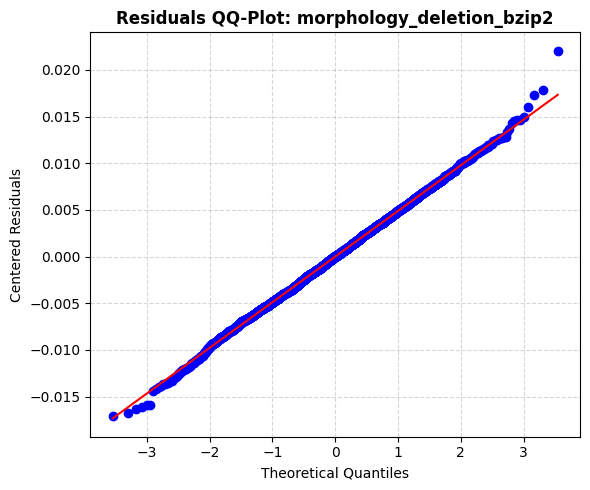

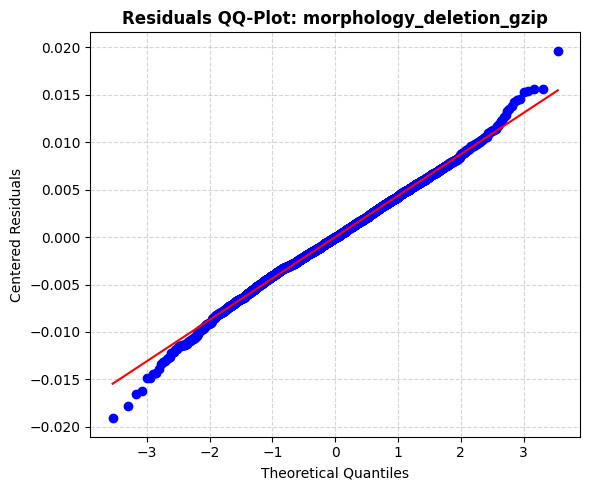

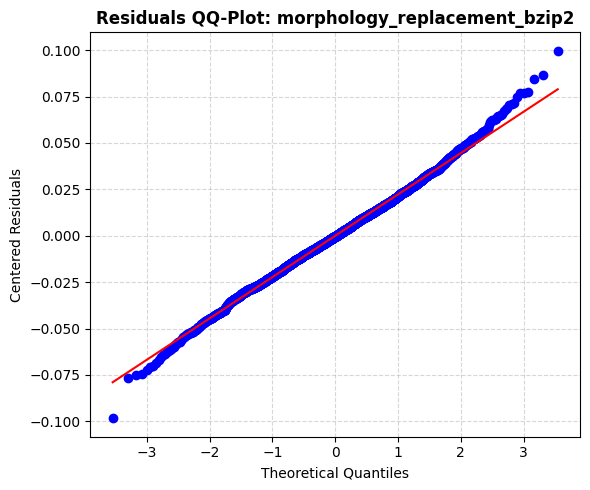

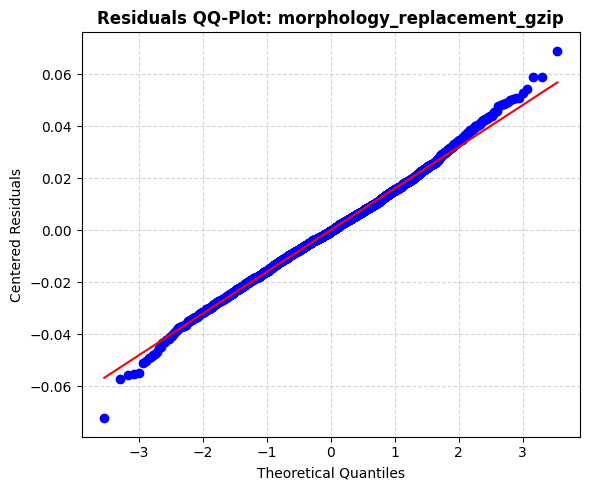

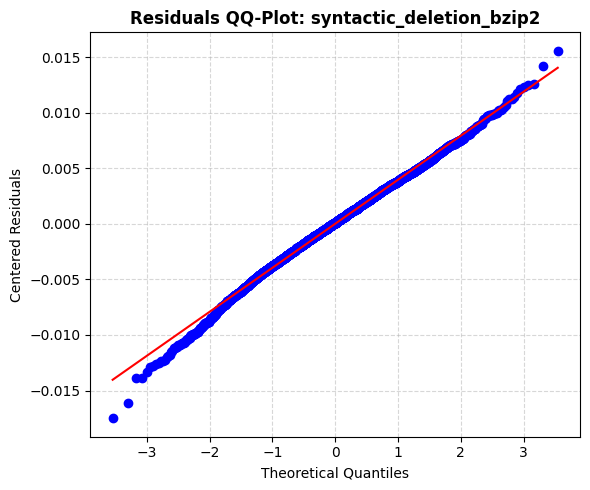

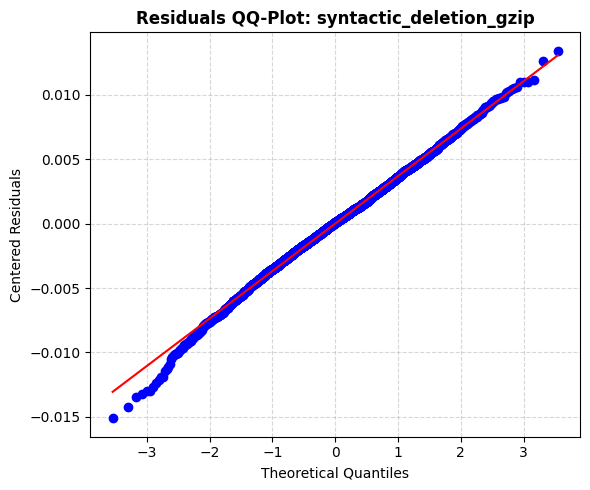

In [7]:
plot_qq_residuals(df=variance_experiments_df, metrics_list=SELECTED_METRICS, target_col='register')

The Q-Q plots show the points aligning with the diagonal, with slight deviations in the tails, typical of approximately normal distributions. We consider the assumption of normality to be met.

#### Homoscedasticity

In [8]:
def plot_homoscedasticity_check(df, metrics_list, target_col='register'):
    """
    Generates grouped residual Boxplots to visually verify homoscedasticity 
    (equal variances) across groups.

    Args:
        df (pd.DataFrame): DataFrame containing the data.
        metrics_list (list): List of numerical columns to analyze.
        target_col (str): Categorical column defining the groups.
    """

    if target_col not in df.columns:
        raise ValueError(f"Target column '{target_col}' not found in DataFrame.")

    print(f"--- Generating Homoscedasticity Check Plots (Grouped by '{target_col}') ---")


    sns.set_style("whitegrid")

    for metric in metrics_list:
        if metric not in df.columns:
            print(f"Warning: Metric '{metric}' not found. Skipping.")
            continue

        # Residuals Calculation
        # Create a temporary dataframe
        temp_df = df[[target_col, metric]].copy().dropna()
        
        # Subtract the corresponding group mean from each value, centering at zero
        group_means = temp_df.groupby(target_col)[metric].transform('mean')
        temp_df['residuals'] = temp_df[metric] - group_means

        # Minimum data check
        if temp_df.empty or temp_df[target_col].nunique() < 2:
            print(f"Insufficient data or groups for '{metric}'.")
            continue

        #  Visualization
        plt.figure(figsize=(10,10))
        
        # Boxplot: Shows the IQR (Interquartile Range) - where the central 50% of data lies
        sns.boxplot(x=target_col, y='residuals', data=temp_df, 
                    showmeans=True,  # Shows the mean 
                    meanprops={"marker":"s","markerfacecolor":"white", "markeredgecolor":"black"},
                    palette="vlag",   # Soft color palette
                    linewidth=1.5,
                    fliersize=0)      # Hide outliers from the boxplot (they will be shown in the stripplot)
        
        # Strip Plot: Shows individual points (helps visualize real density and sample size)
        sns.stripplot(x=target_col, y='residuals', data=temp_df, 
                      color=".3",     # Dark gray
                      alpha=0.5,      # Transparency to see overlap
                      jitter=True)    # Jitter points laterally for better visibility
        
        # Reference line at zero
        plt.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.7)

        plt.title(f'Homoscedasticity Check: {metric}\n(Residuals by Group)', fontweight='bold')
        plt.xlabel(f"Groups ({target_col})")
        plt.ylabel("Centered Residuals")
        
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()

        output_dir = "figures"
        os.makedirs(output_dir, exist_ok=True)
        plt.savefig(os.path.join(output_dir, f"homoscedasticity_boxplot_{metric}.pdf"), 
                    format='pdf', bbox_inches='tight')
        plt.show()

In [9]:
def plot_homoscedasticity_check(df, metrics_list, target_col='register'):
    """
    Generates grouped residual Boxplots to visually verify homoscedasticity 
    and calculates the ratio of maximum to minimum group variance (smax/smin).

    Args:
        df (pd.DataFrame): DataFrame containing the data.
        metrics_list (list): List of numerical columns to analyze.
        target_col (str): Categorical column defining the groups.
    
    Returns:
        pd.DataFrame: A table containing the variance ratio for each metric.
    """

    if target_col not in df.columns:
        raise ValueError(f"Target column '{target_col}' not found in DataFrame.")

    print(f"--- Generating Homoscedasticity Check Plots & Variance Ratios (Grouped by '{target_col}') ---")

    sns.set_style("whitegrid")
    
    # List to store ratio results
    variance_stats = []

    for metric in metrics_list:
        if metric not in df.columns:
            print(f"Warning: Metric '{metric}' not found. Skipping.")
            continue

        # Residuals Calculation
        temp_df = df[[target_col, metric]].copy().dropna()
        
        # Subtract the corresponding group mean from each value (center at zero)
        group_means = temp_df.groupby(target_col)[metric].transform('mean')
        temp_df['residuals'] = temp_df[metric] - group_means

        # Minimum data check
        if temp_df.empty or temp_df[target_col].nunique() < 2:
            print(f"Insufficient data or groups for '{metric}'.")
            continue

        # Variance Ratio Calculation
        # Calculate variance of residuals for each group
        group_variances = temp_df.groupby(target_col)['residuals'].var()
        
        # Identify max and min variance and their GROUP NAMES
        s_max = group_variances.max()
        max_group_name = group_variances.idxmax()  
        
        s_min = group_variances.min()
        min_group_name = group_variances.idxmin()  
        
        # Calculate Ratio 
        if s_min > 0:
            ratio = s_max / s_min
        else:
            ratio = np.inf  # Infinite ratio if minimum variance is 0

        # Store result
        variance_stats.append({
            'Metric': metric,
            'Max Group': max_group_name,
            'S_Max (Max Var)': s_max,
            'Min Group': min_group_name,
            'S_Min (Min Var)': s_min,
            'Ratio (S_Max/S_Min)': ratio
        })

        # Visualization
        plt.figure(figsize=(10, 8))
        
        # Boxplot
        sns.boxplot(x=target_col, y='residuals', data=temp_df, 
                    showmeans=True, 
                    meanprops={"marker":"s","markerfacecolor":"white", "markeredgecolor":"black"},
                    palette="vlag", 
                    linewidth=1.5,
                    fliersize=0) 
        
        # Strip Plot
        sns.stripplot(x=target_col, y='residuals', data=temp_df, 
                      color=".3", 
                      alpha=0.5, 
                      jitter=True)
        
        # Reference line
        plt.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.7)

        plt.title(f'Homoscedasticity Check: {metric}\nVariance Ratio ($S_{{max}}/S_{{min}}$): {ratio:.2f}', fontweight='bold')
        plt.xlabel(f"Groups ({target_col})")
        plt.ylabel("Centered Residuals")
        
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()

        output_dir = "figures"
        os.makedirs(output_dir, exist_ok=True)
        plt.savefig(os.path.join(output_dir, f"homoscedasticity_boxplot_{metric}.pdf"), 
                    format='pdf', bbox_inches='tight')
        plt.show()

    # Create and return the DataFrame summary
    results_df = pd.DataFrame(variance_stats)
    return results_df

--- Generating Homoscedasticity Check Plots & Variance Ratios (Grouped by 'register') ---


/tmp/ipykernel_1011576/3971360221.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_col, y='residuals', data=temp_df,


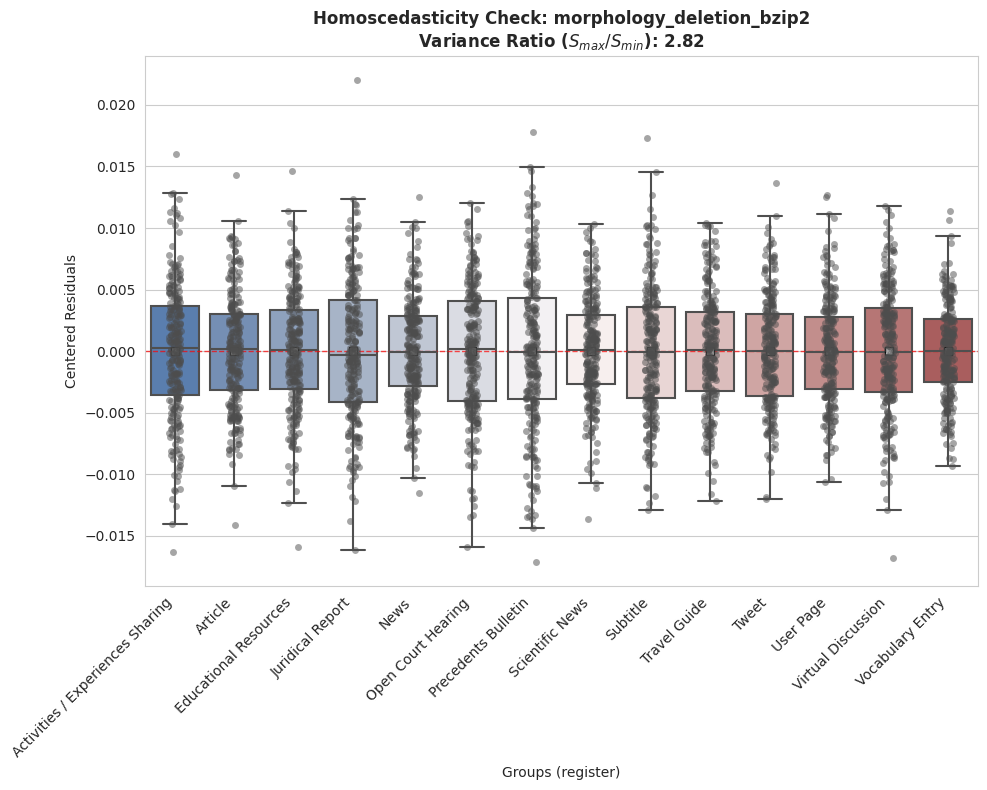

/tmp/ipykernel_1011576/3971360221.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_col, y='residuals', data=temp_df,


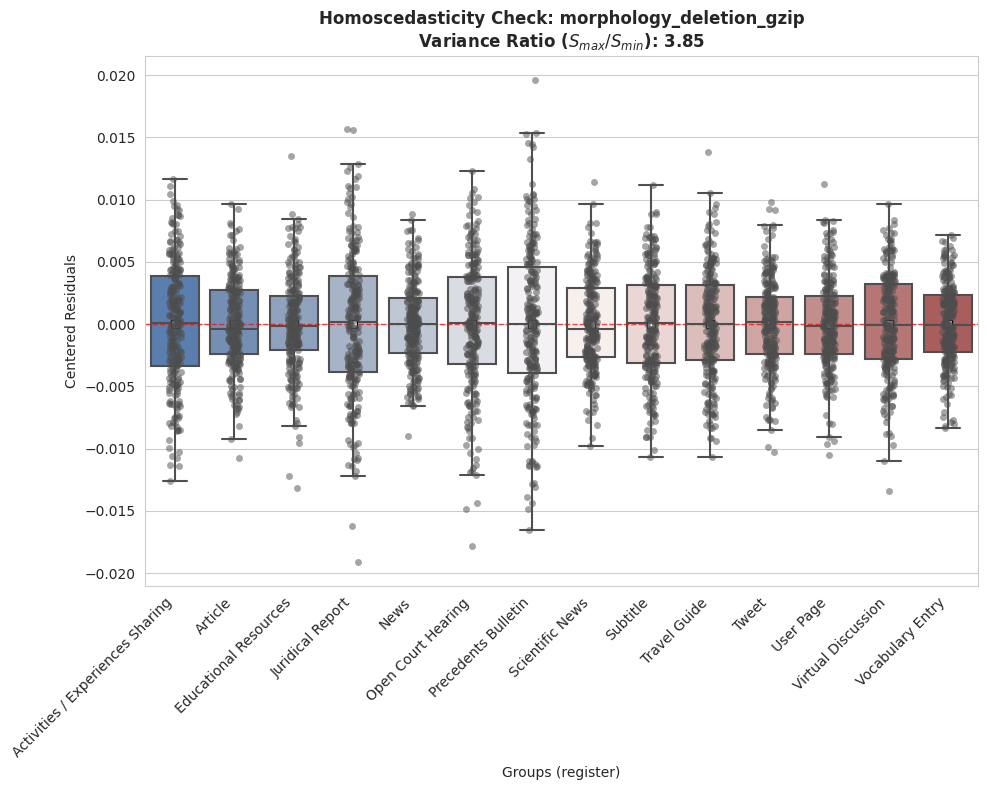

/tmp/ipykernel_1011576/3971360221.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_col, y='residuals', data=temp_df,


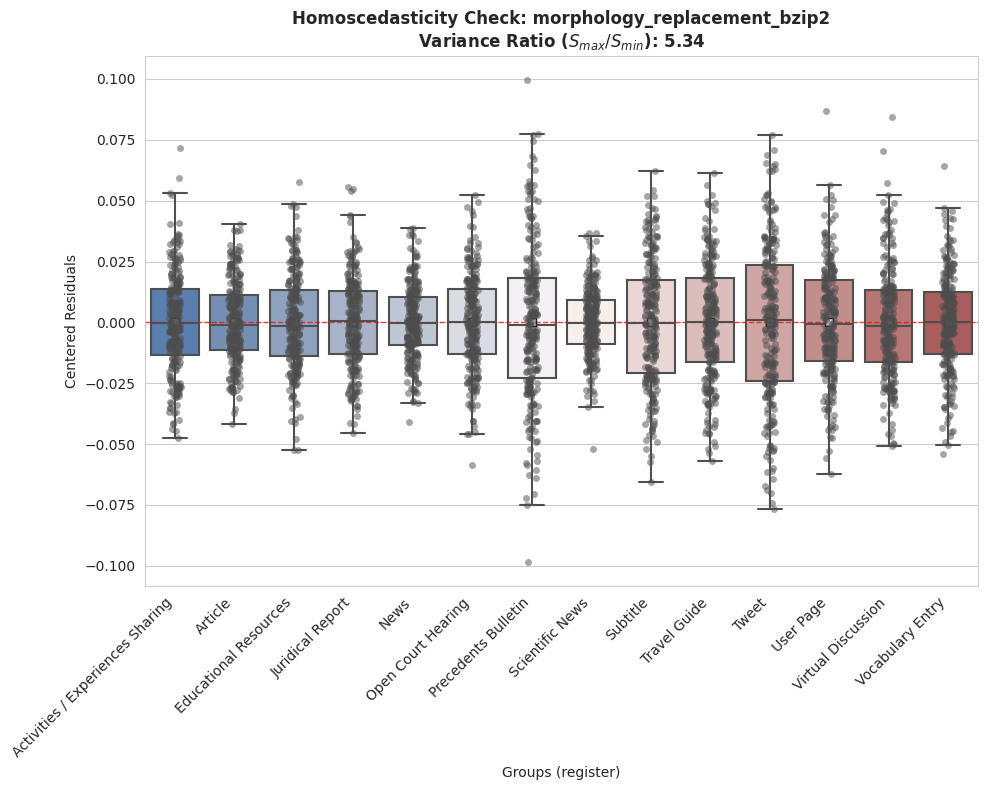

/tmp/ipykernel_1011576/3971360221.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_col, y='residuals', data=temp_df,


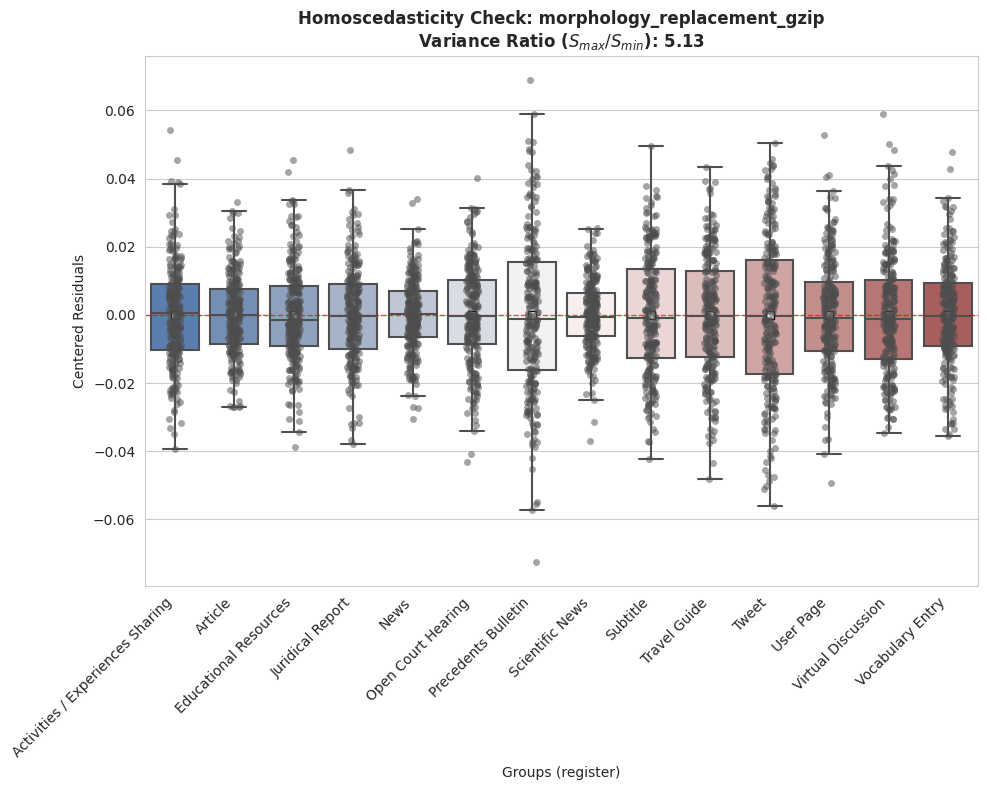

/tmp/ipykernel_1011576/3971360221.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_col, y='residuals', data=temp_df,


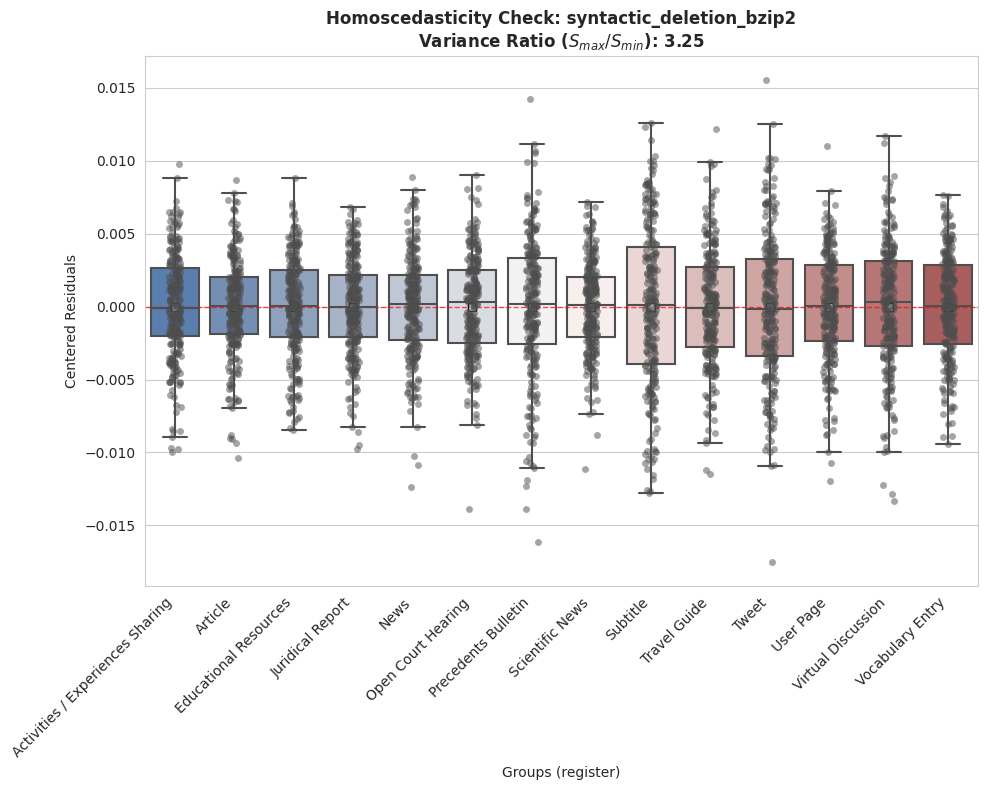

/tmp/ipykernel_1011576/3971360221.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_col, y='residuals', data=temp_df,


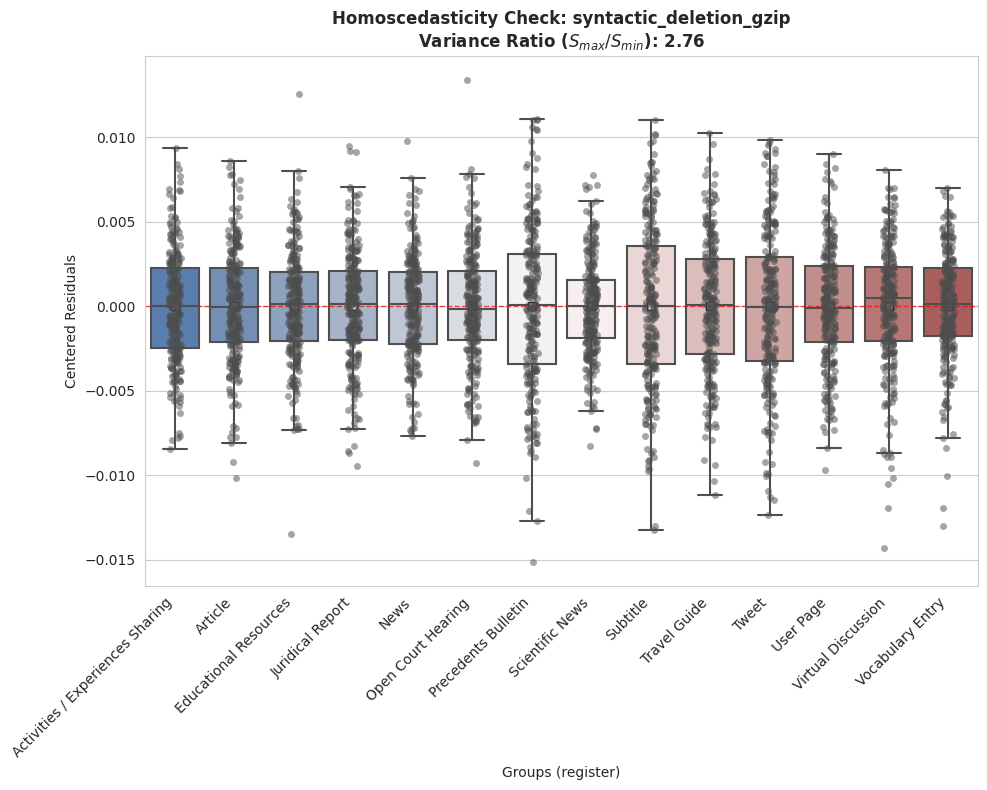

,Metric,Max Group,S_Max (Max Var),Min Group,S_Min (Min Var),Ratio (S_Max/S_Min)
0,morphology_deletion_bzip2,Precedents Bulletin,0.000041,Vocabulary Entry,0.000015,2.818547
1,morphology_deletion_gzip,Precedents Bulletin,0.000040,Vocabulary Entry,0.000010,3.852489
2,morphology_replacement_bzip2,Tweet,0.001023,Scientific News,0.000192,5.336494
3,morphology_replacement_gzip,Precedents Bulletin,0.000528,Scientific News,0.000103,5.128187
4,syntactic_deletion_bzip2,Subtitle,0.000031,Scientific News,0.000010,3.251999
5,syntactic_deletion_gzip,Subtitle,0.000023,Scientific News,0.000008,2.755183


In [10]:
plot_homoscedasticity_check(df=variance_experiments_df, metrics_list=SELECTED_METRICS, target_col='register')

Based on the rule of thumb of smax​/smin​<3, deletion metrics satisfy the assumption. Replacement-based metrics do not; however, the test remains robust in these cases due to the balanced design. We consider this sufficient to proceed, noting that results for deletion metrics are likely more reliable. Furthermore, visual inspection of the plots reveals generally well-behaved distributions and variances.

## ANOVA

In [11]:
def analyze_standard_anova_table(df, metrics_list, target_col='register'):
    """
    Performs One-Way ANOVA, calculates Eta-Squared, and returns a summary table.
    
    Args:
        df (pd.DataFrame): Dataframe containing the data.
        metrics_list (list): List of numeric columns.
        target_col (str): Categorical column (groups).
        
    Returns:
        pd.DataFrame: Statistical results sorted by Eta-Squared (Effect Magnitude).
    """
    results = []
    
    if target_col not in df.columns:
        raise ValueError(f"Target column '{target_col}' not found.")

    print(f"--- Running Standard ANOVA by '{target_col}' ---")

    for metric in metrics_list:
        if metric not in df.columns:
            print(f"Warning: Metric '{metric}' not found. Skipping.")
            continue

        # Data Preparation
        # Group data by category and remove NaNs
        groups_data = [group[1].dropna().values for group in df.groupby(target_col)[metric]]
        # We need at least 2 groups to compare
        if len(groups_data) < 2:
            continue

        # Standard ANOVA Test (F-test and P-value)
        try:
            stat, p_value = f_oneway(*groups_data)
        except Exception as e:
            print(f"Error calculating ANOVA for {metric}: {e}")
            stat, p_value = None, None

        # Manual Calculation of Eta-Squared 
        try:
            # Concatenates all groups into a single array to calculate the grand mean
            all_data = np.concatenate(groups_data)
            grand_mean = np.mean(all_data)

            # SS_total: Sum of squares total (distance from each point to the grand mean)
            ss_total = np.sum((all_data - grand_mean)**2)

            # SS_within: Sum of squares within groups (distance from points to their group mean)
            ss_within = np.sum([np.sum((g - np.mean(g))**2) for g in groups_data])

            # SS_between: Sum of squares between groups
            ss_between = ss_total - ss_within

            # Final calculation of Eta Squared
            eta_squared = ss_between / ss_total if ss_total != 0 else 0

        except Exception as e:
            print(f"Error calculating Eta Squared for {metric}: {e}")
            eta_squared = None

        is_significant = p_value < 0.05 if p_value is not None else False

        # Basic Effect Size classification 
        effect_size_label = 'Negligible'
        if eta_squared is not None:
            if eta_squared >= 0.14: effect_size_label = 'Large'
            elif eta_squared >= 0.06: effect_size_label = 'Medium'
            elif eta_squared >= 0.01: effect_size_label = 'Small'

        results.append({
            'Metric': metric,
            'F-Statistic': stat,
            'P-Value': p_value,
            'Eta-Squared': eta_squared,
            'Effect Size': effect_size_label, 
            'Significant': is_significant
        })

    # DataFrame Creation and Sorting
    results_df = pd.DataFrame(results)
    
    if not results_df.empty:
        results_df = results_df.sort_values(by='Eta-Squared', ascending=False).reset_index(drop=True)

    return results_df

In [12]:
df_results = analyze_standard_anova_table(df=variance_experiments_df, metrics_list=SELECTED_METRICS, target_col='register')

--- Running Standard ANOVA by 'register' ---


In [13]:
df_results

,Metric,F-Statistic,P-Value,Eta-Squared,Effect Size,Significant
0,morphology_deletion_bzip2,5988.981961,0.000000e+00,0.957144,Large,True
1,morphology_deletion_gzip,5957.920430,0.000000e+00,0.956931,Large,True
2,morphology_replacement_bzip2,3756.886363,0.000000e+00,0.933379,Large,True
3,morphology_replacement_gzip,1578.461945,0.000000e+00,0.854786,Large,True
4,syntactic_deletion_bzip2,78.399495,4.799011e-183,0.226226,Large,True
5,syntactic_deletion_gzip,67.923552,4.447779e-160,0.202107,Large,True
